# Ejercicio 4 


In [39]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

Vamos a construir las matrices de datos W apartir de una matriz D. 
Los elementos de la matriz tienen media cero y desviasión estándar 1. Además de que en este mismo código calculamos los autovalores reales. El código lo reciclamos del ejercicio anterior.

In [40]:


def matriz_wishart(N, T):
    D = np.random.normal(0, 1, size=(N, T))
    W = (D @ D.T) / T
    return W 


autovalores_WOE = []


for i in range(miembros):
    W = matriz_wishart(N, T)
    autovalores = np.linalg.eigvalsh(W)
    autovalores_WOE.extend(autovalores)

Ahora vamos a construir la matriz X_n_n con valores en la diagonal c 
Los valores de c van a variar c = 0, 0.2, 0.5 y 0.9

In [41]:
def Xi(N, c):
    Xi = np.full((N,N),c, dtype= float)
    np.fill_diagonal(Xi, 1)
    return Xi


Vamos a construir los datos correlacionados $X = X_{n}^{1/2}* D$

In [42]:

def matriz_D(N, T):
    D = np.random.normal(0, 1, size=(N, T))
    return D
def X(N,T,c):
    D = matriz_D(N, T)
    Xi_mat = Xi(N, c)
    Xi_sqrt = sqrtm(Xi_mat)
    X = Xi_sqrt @ D
    return X

def C(N,T,c):
    X_math = X(N,T,c)
    C = (X_math @ X_math.T) / T
    return C


In [43]:
N = 200
T = 500
c =  [0, 0.2, 0.5,  0.9]

In [44]:
autovalores_C = [[], [], [], []]
for j, valor in enumerate(c):
    for i in range(miembros):
        C_math = C(N,T,valor)
        autovalores = np.linalg.eigvalsh(C_math)
        autovalores_C[j].extend(autovalores)
    autovalores_C[j] = np.array(autovalores_C[j])


In [45]:
autovalores_C[3]

array([1.47471137e-02, 1.55501837e-02, 1.59556614e-02, ...,
       2.53227456e-01, 2.57018831e-01, 1.74242040e+02], shape=(20000,))

In [47]:
kappa = T / N

In [48]:
def rho_teorica(lambdas, c, kappa):
    lambda_menos = (1 - c) * (kappa**(-0.5) - 1)**2
    lambda_mas   = (1 - c) * (kappa**(-0.5) + 1)**2

    rho = np.zeros_like(lambdas)

    mascara = (lambdas >= lambda_menos) & (lambdas <= lambda_mas)

    rho[mascara] = (
        kappa
        * np.sqrt(
            (lambda_mas - lambdas[mascara])
            * (lambdas[mascara] - lambda_menos)
        )
        / (2 * np.pi * (1 - c) * lambdas[mascara])
    )

    return rho


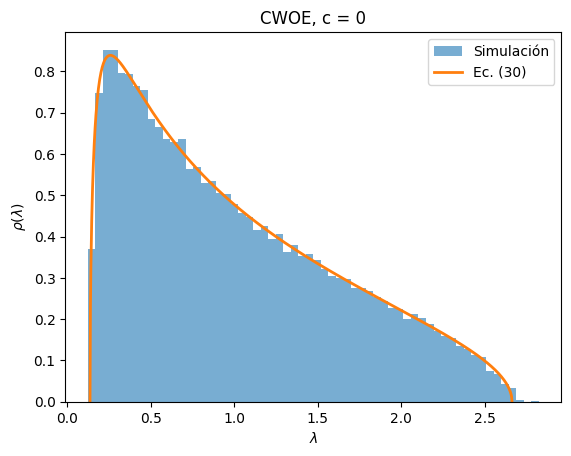

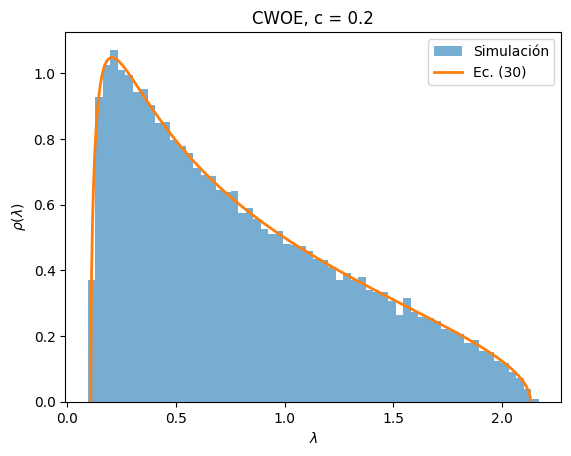

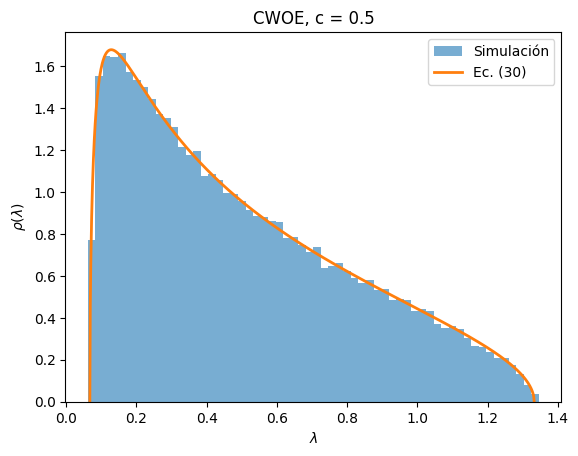

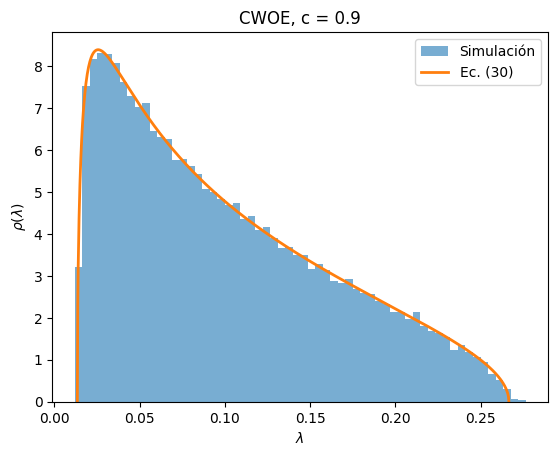

In [49]:
for i, ci in enumerate(c):

    # Recuperamos las 100 realizaciones de N autovalores cada una
    valores = autovalores_C[i].reshape(miembros, N)

    # Para c > 0 aparece un autovalor colectivo separado
    if ci == 0:
        bulk = valores.ravel()
    else:
        bulk = valores[:, :-1].ravel()

    # Bordes teóricos
    lambda_menos = (1 - ci) * (kappa**(-0.5) - 1)**2
    lambda_mas   = (1 - ci) * (kappa**(-0.5) + 1)**2

    lambdas = np.linspace(lambda_menos, lambda_mas, 1000)
    rho = rho_teorica(lambdas, ci, kappa)

    plt.hist(
        bulk,
        bins=60,
        density=True,
        alpha=0.6,
        label="Simulación"
    )

    plt.plot(
        lambdas,
        rho,
        linewidth=2,
        label="Ec. (30)"
    )

    plt.xlabel(r"$\lambda$")
    plt.ylabel(r"$\rho(\lambda)$")
    plt.title(f"CWOE, c = {ci}")
    plt.legend()
    plt.show()

In [50]:
def lambda_colectivo(N, kappa, c):
    return ((N*c + 1 - c) * (N*c*kappa + 1 - c)) / (N*c*kappa)

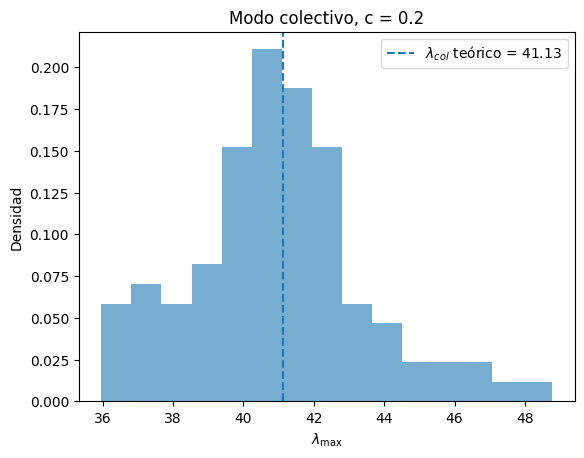

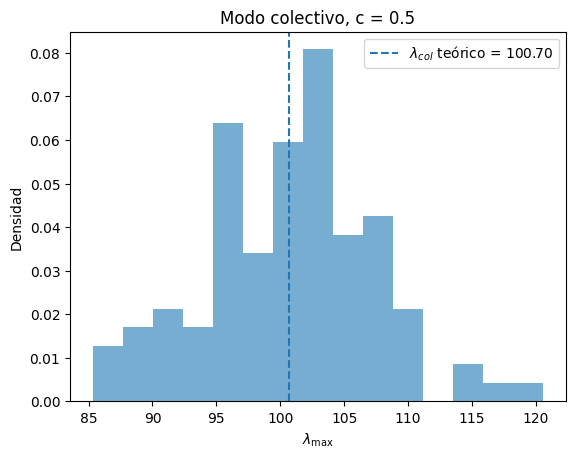

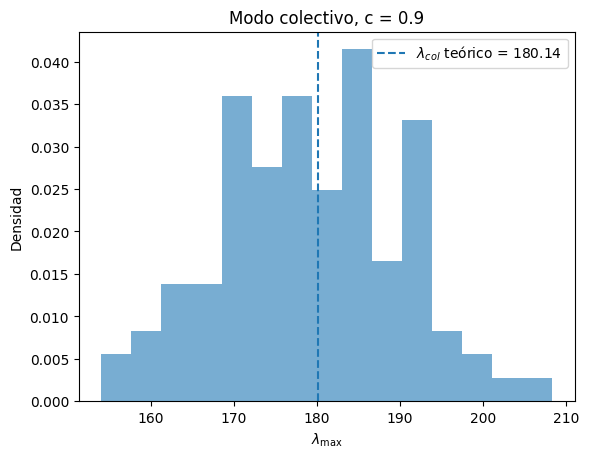

In [51]:
for i, ci in enumerate(c):

    if ci == 0:
        continue

    valores = autovalores_C[i].reshape(miembros, N)
    maximos = valores[:, -1]

    lambda_teorico = lambda_colectivo(N, kappa, ci)

    plt.hist(maximos, bins=15, density=True, alpha=0.6)
    plt.axvline(
        lambda_teorico,
        linestyle="--",
        label=fr"$\lambda_{{col}}$ teórico = {lambda_teorico:.2f}"
    )

    plt.xlabel(r"$\lambda_{\max}$")
    plt.ylabel("Densidad")
    plt.title(f"Modo colectivo, c = {ci}")
    plt.legend()
    plt.show()